# Exploratory Data Analysis | Titanic Dataset

This notebook explores the Kaggle Titanic training dataset to understand feature distributions,
missing data patterns, and relationships between passenger attributes and survival.

## 1. Imports and Data Loading

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

from titanic_ml.data_loader import load_data, validate_schema
from titanic_ml.visualization import (
    plot_survival_rate,
    get_percentage_missing_values,
    plot_correlation_heatmap,
    plot_distribution,
)

# Ensures plots display right below the cells.
%matplotlib inline

In [80]:
df = load_data("../data/train.csv")
validate_schema(df, is_training=True)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 891 rows, 12 columns


## 2. Data Overview

In [81]:
print('DataFrame sample data:\n')
display(df.head())

print('DataFrame structure overview:\n')
df.info()

print('\nDataFrame percentage of missing values per feature:')
missing_summary = get_percentage_missing_values(df)
display(missing_summary[missing_summary["count"] > 0].sort_values("percentage", ascending=False))

print('\nDataFrame numerical features summary statistics:')
df.describe()

DataFrame sample data:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


DataFrame structure overview:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

DataFrame percentage of missing values per feature:


,count,percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467



DataFrame numerical features summary statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Note:**
- `Cabin` has the most missing values (~77 %), making it difficult to use directly.
- `Age` is missing for roughly 20 % of passengers. We can try to impute it.
- `Embarked` has only 2 missing entries. Imputation should be straightforward.

## 3. Survival Rate Analysis

Breaking down survival by key categorical features reveals which groups
had higher or lower chances of surviving.

### 3.1 Overall Survival Rate

In [82]:
overall_rate = df["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.2%}")

Overall survival rate: 38.38%


### 3.2 Survival Rate by Feature

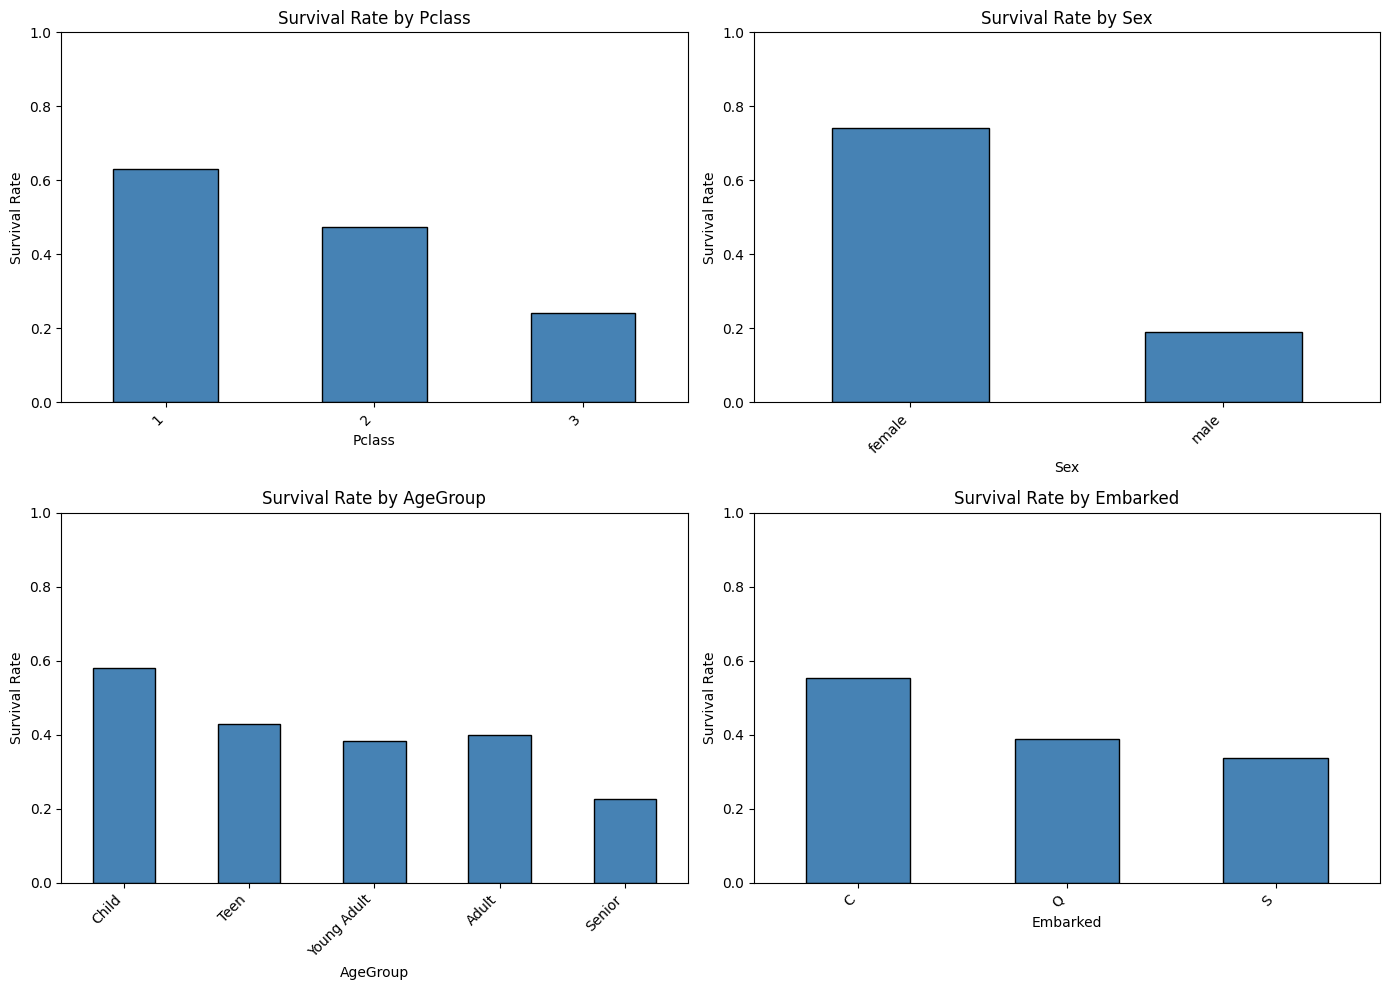

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival rate by passenger class. Higher-class might have better access to lifeboats and/or life jackets.
plot_survival_rate(df, "Pclass", ax=axes[0, 0])

# Survival rate by sex and age. "Woman and children first" could drive higher survival rate for women (compared to men) and for children (compared to adults).
plot_survival_rate(df, "Sex", ax=axes[0, 1])
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
)
plot_survival_rate(df, "AgeGroup", ax=axes[1, 0])

# Survival rate by embarked location. Embarked port location you correlate to cabin position on the boat and socio-economic status.
plot_survival_rate(df, "Embarked", ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 4. Correlation Heatmap

A correlation matrix of numeric features helps identify which variables
move together and which might be redundant or strongly predictive of survival.

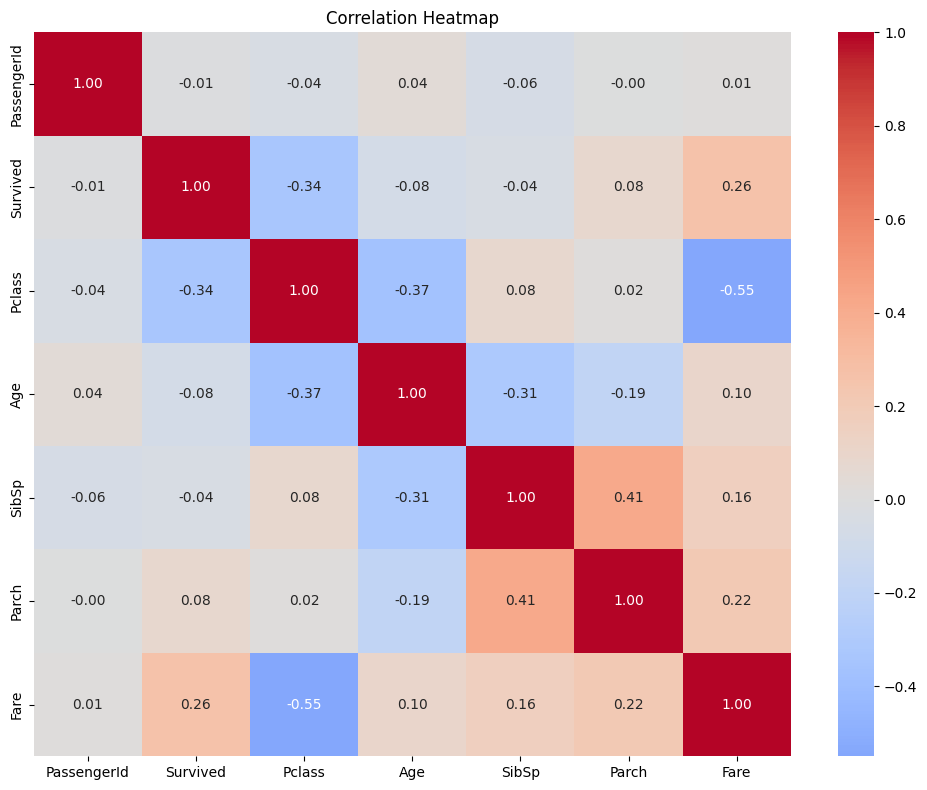

In [84]:
fig = plot_correlation_heatmap(df)
fig

## 5. Feature Distributions

Histograms with KDE overlays for `Age` and `Fare` reveal skewness and outliers
that may need attention during preprocessing.

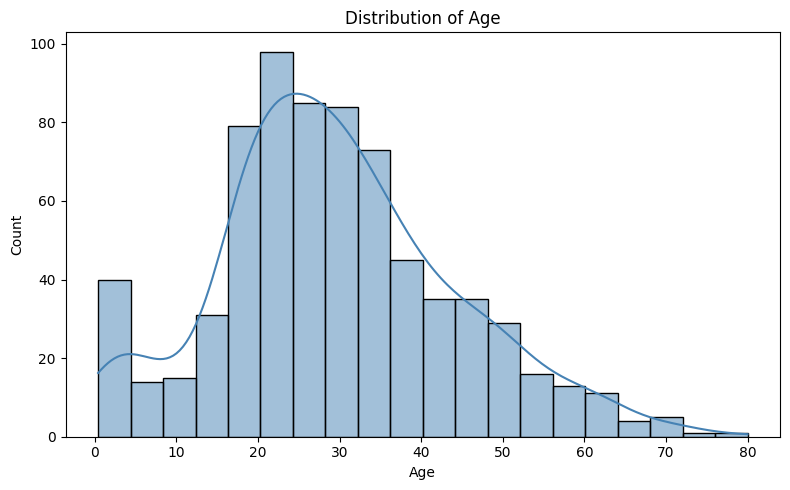

In [85]:
fig = plot_distribution(df, "Age")
fig

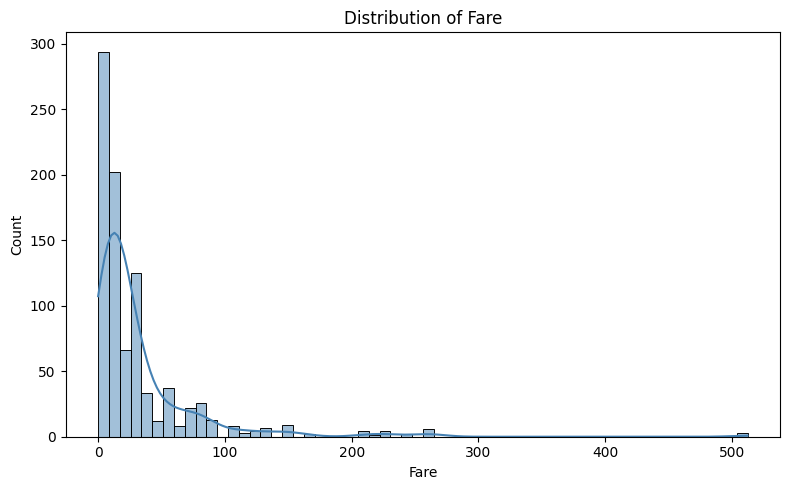

In [86]:
fig = plot_distribution(df, "Fare")
fig

## 6. Name Exploration

In [93]:
# Look at a diverse sample of names from both train and test sets
# We also load the test set here to get a complete picture of all titles
test_df = load_data('../data/test.csv')

print('Sample passenger names (training set):\n')
for name in df['Name'].sample(10, random_state=42).values:
    print(f'  {name}')

print('\nSample passenger names (test set):\n')
for name in test_df['Name'].sample(5, random_state=42).values:
    print(f'  {name}')

Sample passenger names (training set):

  Moubarek, Master. Halim Gonios ("William George")
  Kvillner, Mr. Johan Henrik Johannesson
  Alhomaki, Mr. Ilmari Rudolf
  Harper, Miss. Annie Jessie "Nina"
  Nicola-Yarred, Miss. Jamila
  Barber, Miss. Ellen "Nellie"
  Kelly, Miss. Anna Katherine "Annie Kate"
  Vander Planke, Mr. Leo Edmondus
  Carr, Miss. Helen "Ellen"
  Newsom, Miss. Helen Monypeny

Sample passenger names (test set):

  Krekorian, Mr. Neshan
  Kreuchen, Miss. Emilie
  Canavan, Mr. Patrick
  Cor, Mr. Bartol
  Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)


Note: Clear pattern: every name contains a **title** between a comma and a period. Hence we can extract the title from both datasets.

In [94]:
# Extract title from both datasets
df['Title'] = df['Name'].apply(lambda n: n.split(',')[1].split('.')[0].strip())
test_df['Title'] = test_df['Name'].apply(lambda n: n.split(',')[1].split('.')[0].strip())

# First, let's see ALL raw titles before making any grouping decisions
raw_counts = pd.DataFrame({
    'Train': df['Title'].value_counts(),
    'Test': test_df['Title'].value_counts(),
}).fillna(0).astype(int)
raw_counts['Total'] = raw_counts['Train'] + raw_counts['Test']
raw_counts = raw_counts.sort_values('Total', ascending=False)
print('Raw title counts (before any grouping):\n')
print(raw_counts.to_string())
print(f'\nTotal unique titles: {len(raw_counts)}')

Raw title counts (before any grouping):

              Train  Test  Total
Title                           
Mr              517   240    757
Miss            182    78    260
Mrs             125    72    197
Master           40    21     61
Rev               6     2      8
Dr                7     1      8
Col               2     2      4
Ms                1     1      2
Major             2     0      2
Mlle              2     0      2
Sir               1     0      1
Capt              1     0      1
Mme               1     0      1
Lady              1     0      1
Jonkheer          1     0      1
Dona              0     1      1
Don               1     0      1
the Countess      1     0      1

Total unique titles: 18


In [95]:
# Group equivalent titles (different languages for the same thing)
# Then bucket everything that isn't Mr, Miss, Mrs, Master, Dr, or Rev as 'Other'
equiv_map = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
keep_titles = {'Mr', 'Miss', 'Mrs', 'Master', 'Dr', 'Rev'}

def normalize_title(title):
    title = equiv_map.get(title, title)
    return title if title in keep_titles else 'Other'

df['Title'] = df['Title'].apply(normalize_title)
test_df['Title'] = test_df['Title'].apply(normalize_title)

# Combined view after grouping
combined_counts = pd.DataFrame({
    'Train': df['Title'].value_counts(),
    'Test': test_df['Title'].value_counts(),
}).fillna(0).astype(int)
combined_counts['Total'] = combined_counts['Train'] + combined_counts['Test']
combined_counts = combined_counts.sort_values('Total', ascending=False)
print('Title counts after grouping:\n')
print(combined_counts.to_string())

Title counts after grouping:

        Train  Test  Total
Title                     
Mr        517   240    757
Miss      185    79    264
Mrs       126    72    198
Master     40    21     61
Other      10     3     13
Dr          7     1      8
Rev         6     2      8


In [96]:
# Single summary table: title counts, age stats, and missing age info
# Using training set only (this is what we'd use for imputation)
title_summary = df.groupby('Title').agg(
    Total=('Title', 'count'),
    Age_Known=('Age', 'count'),
    Median_Age=('Age', 'median'),
    Survival_Rate=('Survived', 'mean'),
).sort_values('Total', ascending=False)

title_summary['Age_Missing'] = title_summary['Total'] - title_summary['Age_Known']
title_summary['Survival_Rate'] = title_summary['Survival_Rate'].apply(lambda x: f'{x:.1%}')

print('Title summary (training set):\n')
print(title_summary[['Total', 'Age_Known', 'Age_Missing', 'Median_Age', 'Survival_Rate']].to_string())

Title summary (training set):

        Total  Age_Known  Age_Missing  Median_Age Survival_Rate
Title                                                          
Mr        517        398          119        30.0         15.7%
Miss      185        149           36        21.0         70.3%
Mrs       126        109           17        35.0         79.4%
Master     40         36            4         3.5         57.5%
Other      10         10            0        48.5         50.0%
Dr          7          6            1        46.5         42.9%
Rev         6          6            0        46.5          0.0%


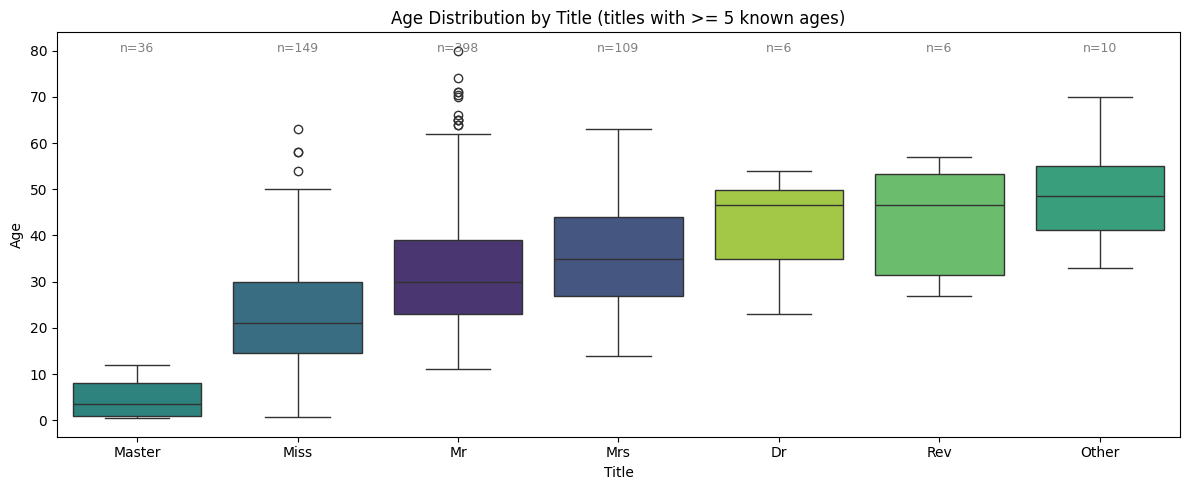

In [99]:
import seaborn as sns

# Generate age box plots per title.
# Only show titles with enough data for a meaningful box (>= 5 known ages)
titles_with_data = title_summary[title_summary['Age_Known'] >= 5].index
plot_df = df[df['Title'].isin(titles_with_data)]
title_order = plot_df.groupby('Title')['Age'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=plot_df, x='Title', y='Age', order=title_order, ax=ax,
            palette='viridis', hue='Title', legend=False)

# Add count annotations
for i, title in enumerate(title_order):
    n = plot_df[plot_df['Title'] == title]['Age'].count()
    ax.text(i, ax.get_ylim()[1] - 2, f'n={n}', ha='center', va='top', fontsize=9, color='gray')

ax.set_title('Age Distribution by Title (titles with >= 5 known ages)')
ax.set_xlabel('Title')
ax.set_ylabel('Age')
plt.tight_layout()
plt.show()

The box plot shows that title could be a strong predictor of Age:
- "Master" is tightly clustered around very young ages
- "Miss" and "Mrs" have clearly different distributions
- "Mr" has the widest spread, covering most of the adult male range

## 7. Key Takeaways

1. **Class matters**: First-class passengers survived at a much higher rate than third-class.
2. **Gender is the strongest signal**: Female passengers had a dramatically higher survival rate.
3. **Age plays a role**: Children had better survival odds; seniors fared worse.
4. **Embarked port**: Cherbourg passengers show a higher survival rate, likely correlated with class.
5. **Missing data**: `Cabin` is mostly missing and will likely be dropped. `Age` needs imputation. `Embarked` needs mode imputation or row deletion (only 2 rows).
6. **Title is highly informative**: Extracted from Name, it encodes gender, social status, and age. It will be used for Age imputation and as a feature in modeling.
7. **Fare is right-skewed**: A few very high fares pull the distribution; consider log-transform or robust scaling.
8. **Pclass and Fare are negatively correlated**: Expected, since higher class means higher fare.

These insights will directly inform the feature engineering pipeline in the next notebook.